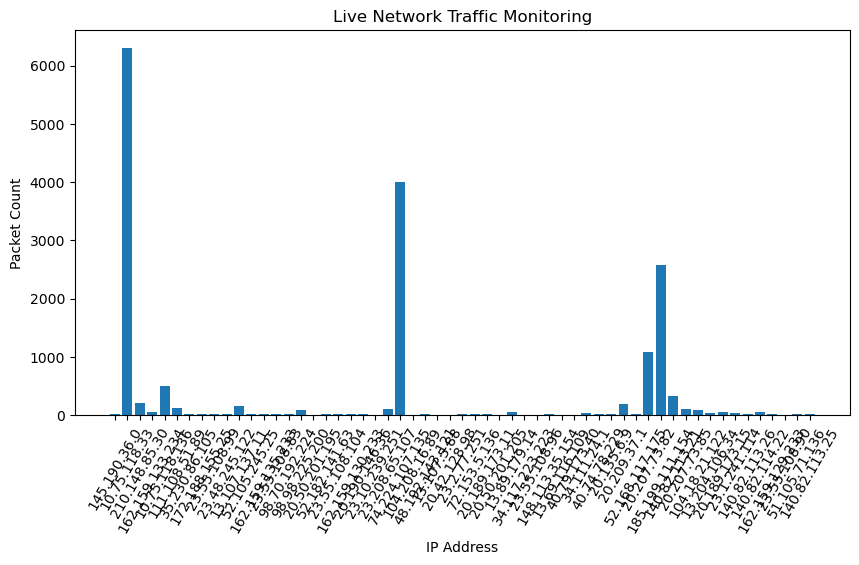

In [10]:
# Install libraries (run once)
!pip install scapy pandas plotly

from scapy.all import sniff, IP
import pandas as pd
from collections import defaultdict
import plotly.express as px
import threading

# ==========================
# Storage
# ==========================

packet_count = defaultdict(int)
suspicious_ips = set()

# ==========================
# Packet processing
# ==========================

def process_packet(packet):

    if packet.haslayer(IP):

        src_ip = packet[IP].src
        packet_count[src_ip] += 1

        # suspicious detection
        if packet_count[src_ip] > 500 and src_ip not in suspicious_ips:
            suspicious_ips.add(src_ip)
            print(f"⚠ Suspicious traffic detected from {src_ip}")

# ==========================
# Packet sniffing
# ==========================

def start_sniffing():

    print("🔍 Monitoring network traffic...")

    sniff(
        prn=process_packet,
        store=False,
        filter="ip",
        count=600,
        timeout=60
    )

    print("✅ Monitoring finished")

thread = threading.Thread(target=start_sniffing)
thread.start()
thread.join()

# ==========================
# Prepare Data
# ==========================

df = pd.DataFrame(list(packet_count.items()),
                  columns=["IP Address","Packets"])

df = df.sort_values(by="Packets", ascending=False)

print("\n📋 All IP Addresses Captured:")
display(df)

# ==========================
# Animated Bar Chart
# ==========================

bar = px.bar(
    df,
    x="IP Address",
    y="Packets",
    color="Packets",
    title="📊 Network Traffic Monitoring",
    animation_frame="Packets"
)

bar.show()

# ==========================
# Pie Chart
# ==========================

pie = px.pie(
    df,
    names="IP Address",
    values="Packets",
    title="🥧 Traffic Distribution"
)

pie.show()

# ==========================
# Suspicious IP list
# ==========================

print("\n⚠ Suspicious IP Addresses:")

for ip in suspicious_ips:
    print(ip)